# Make a 2D/3D box around Kirishima, add Cerjean boundaries, propagate elastic and acoustic waves and thermal diffusion

In [1]:
# Locate flexOPT securely without relying on @__DIR__ (unreliable in IJulia).
# If this notebook is outside the repository, set ENV["FLEXOPT_ROOT"] first.
import Pkg

function find_flexopt_root(start_dir=pwd())
    candidates = String[]
    if haskey(ENV, "FLEXOPT_ROOT")
        push!(candidates, abspath(expanduser(ENV["FLEXOPT_ROOT"])))
    end
    directory = abspath(start_dir)
    while true
        push!(candidates, directory)
        parent = dirname(directory)
        parent == directory && break
        directory = parent
    end
    for candidate in unique(candidates)
        project_file = joinpath(candidate, "Project.toml")
        source_dir = joinpath(candidate, "src")
        if isfile(project_file) && isfile(joinpath(source_dir, "commonBatchs.jl"))
            return candidate
        end
    end
    error("Cannot locate flexOPT. Start Jupyter inside the repository or set ENV[\"FLEXOPT_ROOT\"] to its absolute path.")
end

flexopt_root = find_flexopt_root()
Pkg.activate(flexopt_root)
@show VERSION Threads.nthreads() Base.active_project()

# flexOPT reads this backend during module construction. CPU is selected
# automatically unless CUDA/Metal was explicitly loaded beforehand.
include(joinpath(flexopt_root, "src", "batchFiles", "batchGPU.jl"))
include(joinpath(flexopt_root, "src", "commonBatchs.jl"))
include(joinpath(flexopt_root, "src", "planet1D.jl"))
planet1D.configure_input!()
include(joinpath(flexopt_root, "src", "GeoPoints.jl"))
using .commonBatchs, .planet1D, .GeoPoints
include(joinpath(flexopt_root, "src", "seismicStations.jl"))
using .seismicStations
include(joinpath(flexopt_root, "src", "elasticWave2D.jl"))
using .elasticWave2D
include(joinpath(flexopt_root, "src", "fieldOutput.jl"))
using .fieldOutput
include(joinpath(flexopt_root, "src", "elasticWave3D.jl")) # ordinary solver (not OPT)
using .elasticWave3D
include(joinpath(flexopt_root, "src", "flexOPT.jl"))
using .flexOPT


  Activating 

VERSION = v"1.12.6"
Threads.nthreads() = 8
Base.active_project() = "/Users/nobuaki/Documents/Github/flexOPT/Project.toml"
→ Using CPU backend (no GPU detected)

project at `~/Documents/Github/flexOPT`



Selected backend type: CPU


In [2]:
using GLMakie
using Statistics
using LinearAlgebra, SparseArrays
using Markdown
GLMakie.activate!()

# making an initial model

In [3]:
# Kirishima summit and the active Hi-net station N.MJNH fit in one
# 10 × 10 km square when the model is centred halfway between them.
kirishimaSummit = GeoPoint(dmsToDecimal(31,56,03), dmsToDecimal(130,51,42))
#miyakonojōStation = GeoPoint(31.8643, 130.9454)
#p0 = GeoPoint(
#    (kirishimaSummit.lat + miyakonojōStation.lat) / 2,
#    (kirishimaSummit.lon + miyakonojōStation.lon) / 2,
#)
p0=kirishimaSummit
Δx = 200.0 # in metre
Δy = 200.0
Δz = 200.0
altMax = 2.e3 # in metre
altMin = -40.e3 # in metre
# constructLocalBox spans [-horizontalHalfWidth, +horizontalHalfWidth],
# hence 5 km gives a strict 10 km × 10 km horizontal model.
horizontalHalfWidth = 40.e3
boxGrids3D = constructLocalBox(
    p0, Δx, Δy, Δz,
    -horizontalHalfWidth, horizontalHalfWidth,
    -horizontalHalfWidth, horizontalHalfWidth,
    altMin, altMax,
)

# The source may be a URL or a local ALJ-format ZIP file. Change only this
# value to use a mirror, a future NIED release, or a downloaded archive.
niedVelocitySource = DEFAULT_NIED_VELOCITY_SOURCE[]
# niedVelocitySource = "/absolute/path/to/ALJ2023.zip"

# Include the source identity in the outer model cache name. The NIED archive
# and parsed arrays also have their own cache under DEFAULT_NIED_VELOCITY_CACHE.
velocitySourceKey = nied_velocity_source_key(niedVelocitySource)
modelCacheName = "seismicModel3D_Kirishima_10km_NIED_$(velocitySourceKey)"
seismicModel3D = lazyProduceOrLoad(
    modelCacheName,
    getParamsAndTopo,
    boxGrids3D.allGridsInGeoPoints,
    boxGrids3D.effectiveRadii,
    0.1;
    velocity_model=:NIED,
    nied_source=niedVelocitySource,
    nied_confidence_max=0.8,
    nied_outside=:planet1D,
    nied_low_confidence=:planet1D,
)

@show seismicModel3D.velocity_model
@show seismicModel3D.nied_source
@show count(seismicModel3D.nied_mask) / length(seismicModel3D.nied_mask)

centreOption = "p0"
Loading from ./tmp/seismicModel3D_Kirishima_10km_NIED_67f23ae0694b.jld2
seismicModel3D.velocity_model = :NIED
seismicModel3D.nied_source = "https://www.hinet.bosai.go.jp/topics/sokudo_kozo/dlDialogue.php?ID=ALJ"
count(seismicModel3D.nied_mask) / length(seismicModel3D.nied_mask) = 0.9497318681054393


0.9497318681054393

## NIED three-dimensional velocity model

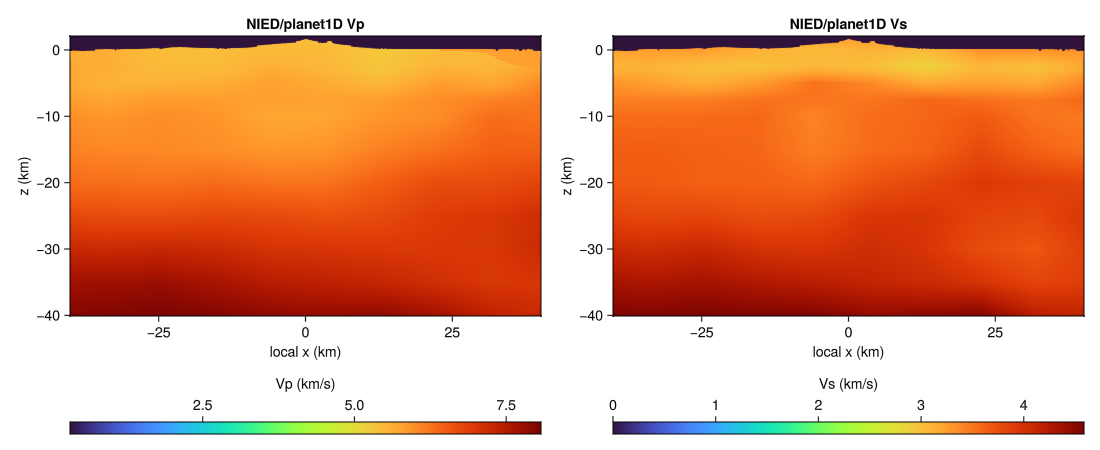

In [4]:
# Central local x-z section. Values outside NIED coverage or above the
# confidence threshold retain the planet1D fallback.
xVelocity = [p.xyz[1] for p in boxGrids3D.allGridsInCartesian[:, 1, 1]] .* 1e-3
zVelocity = [p.xyz[3] for p in boxGrids3D.allGridsInCartesian[1, 1, :]] .* 1e-3
middleY = cld(boxGrids3D.Ny, 2)

velocityFigure = Figure(size=(1100, 450))
vpAxis = Axis(velocityFigure[1, 1]; xlabel="local x (km)", ylabel="z (km)", title="NIED/planet1D Vp")
vsAxis = Axis(velocityFigure[1, 2]; xlabel="local x (km)", ylabel="z (km)", title="NIED/planet1D Vs")
vpPlot = heatmap!(vpAxis, xVelocity, zVelocity, seismicModel3D.Vpv[:, middleY, :]; colormap=:turbo)
vsPlot = heatmap!(vsAxis, xVelocity, zVelocity, seismicModel3D.Vsv[:, middleY, :]; colormap=:turbo)
Colorbar(velocityFigure[2, 1], vpPlot; vertical=false, label="Vp (km/s)")
Colorbar(velocityFigure[2, 2], vsPlot; vertical=false, label="Vs (km/s)")
velocityFigure

extrema(topography) = (-0.30000000000000004, 1.7000000000000002)
extrema(surface_normals.nz) = (0.5773502691896175, 1.0)


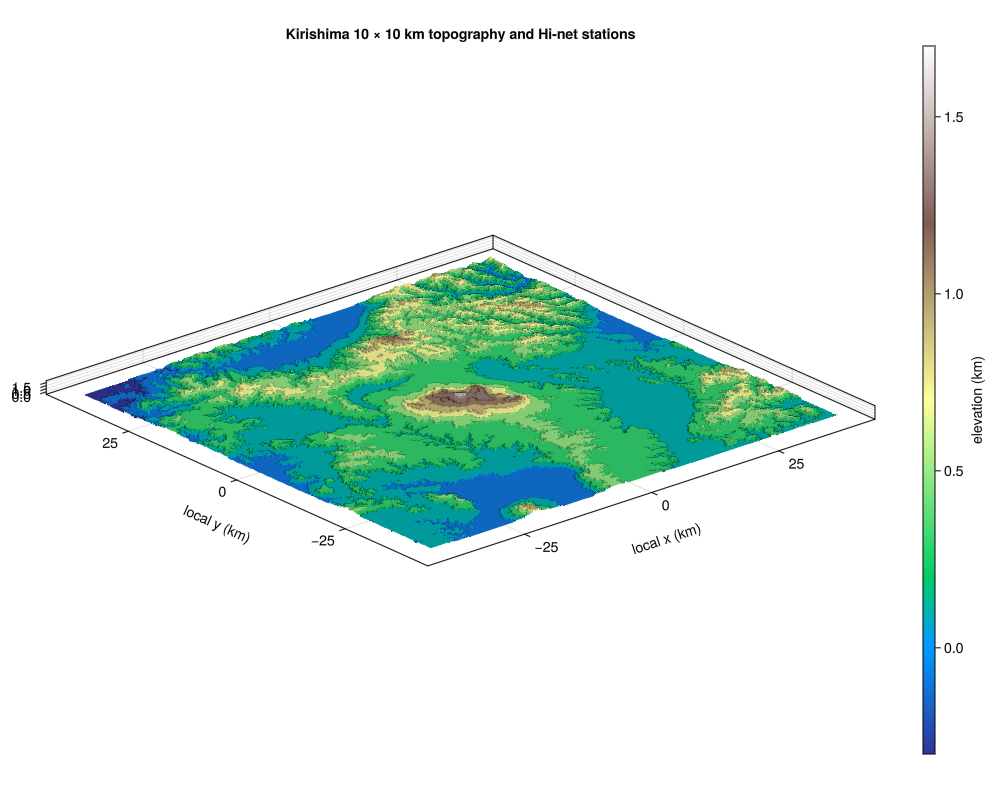

In [5]:
# Cartesian coordinates in km for plotting.
x = [p.xyz[1] for p in boxGrids3D.allGridsInCartesian[:, 1, 1]] .* 1e-3
y = [p.xyz[2] for p in boxGrids3D.allGridsInCartesian[1, :, 1]] .* 1e-3
z = [p.xyz[3] for p in boxGrids3D.allGridsInCartesian[1, 1, :]] .* 1e-3

ρ = seismicModel3D.ρ
air_density_cutoff = 0.01 # getParamsAndTopo uses ρAir = 0.001 by default
material = ρ .> air_density_cutoff

# Locate the material-to-air interface in every vertical column. The
# midpoint gives a surface with vertical uncertainty ≤ Δz/2 (50 m here).
topography = Matrix{Float64}(undef, length(x), length(y))
for j in eachindex(y), i in eachindex(x)
    k = findlast(@view material[i, j, :])
    isnothing(k) && error("No material in column (i, j) = $((i, j))")
    k == length(z) && error("Topography reaches altMax in column (i, j) = $((i, j)); increase altMax")
    all(@view material[i, j, 1:k]) || error("Material mask has a cavity at $((i, j))")
    topography[i, j] = (z[k] + z[k + 1]) / 2
end

# Upward unit normal n = (-∂h/∂x, -∂h/∂y, 1) / ‖·‖.
# Keep these arrays: they are the geometry needed by a later free-surface BC.
dh_dx = similar(topography)
dh_dy = similar(topography)
dh_dx[1, :] .= (topography[2, :] .- topography[1, :]) ./ (x[2] - x[1])
dh_dx[end, :] .= (topography[end, :] .- topography[end-1, :]) ./ (x[end] - x[end-1])
dh_dx[2:end-1, :] .= (topography[3:end, :] .- topography[1:end-2, :]) ./ (x[3:end] .- x[1:end-2])
dh_dy[:, 1] .= (topography[:, 2] .- topography[:, 1]) ./ (y[2] - y[1])
dh_dy[:, end] .= (topography[:, end] .- topography[:, end-1]) ./ (y[end] - y[end-1])
dh_dy[:, 2:end-1] .= (topography[:, 3:end] .- topography[:, 1:end-2]) ./ permutedims(y[3:end] .- y[1:end-2])

normal_scale = @. inv(sqrt(dh_dx^2 + dh_dy^2 + 1))
surface_normals = (
    nx = (@. -dh_dx * normal_scale),
    ny = (@. -dh_dy * normal_scale),
    nz = normal_scale,
)

# GMT-like shaded relief: elevation colors, GL lighting, and contours.
fig = Figure(size = (1000, 800))
ax = Axis3(
    fig[1, 1];
    xlabel = "local x (km)", ylabel = "local y (km)", zlabel = "elevation (km)",
    title = "Kirishima 10 × 10 km topography and Hi-net stations",
    aspect = :data,
)
terrain = surface!(
    ax, x, y, topography;
    color = topography,
    colormap = :terrain,
    colorrange = extrema(topography),
)
contour3d!(
    ax, x, y, topography;
    levels = range(extrema(topography)...; length = 15),
    color = (:black, 0.35),
    linewidth = 1,
)
Colorbar(fig[1, 2], terrain; label = "elevation (km)")

@show extrema(topography) extrema(surface_normals.nz)
fig

## Available seismic stations

NIED stations in geographic request: 11
NIED stations inside local 10 × 10 km box: 11


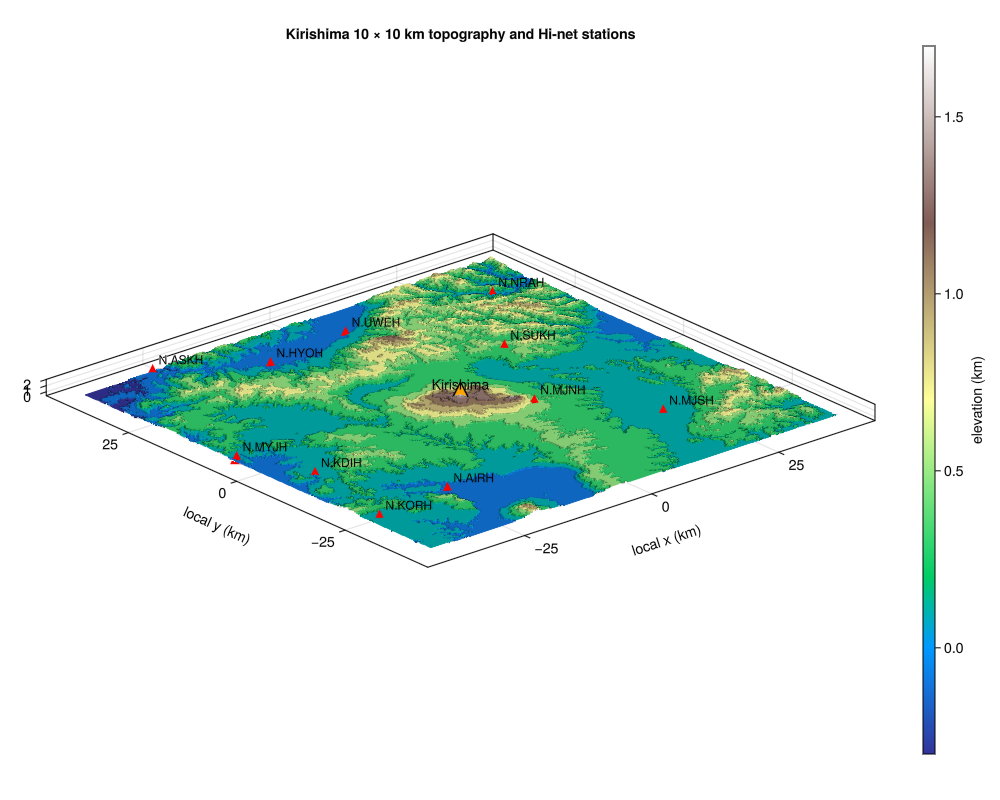

In [6]:
# Query the current public NIED station metadata, then retain stations in
# this model's geographic/local Cartesian box. Waveform download is a
# separate operation and requires a free NIED account.
stationBounds = StationBounds(boxGrids3D.allGridsInGeoPoints)
niedStations = fetch_nied_stations(bounds=stationBounds)

stationOverlay = plot_stations!(
    ax,
    niedStations,
    boxGrids3D;
    units=:km,
    show_boreholes=true,
    labels=true,
)

# Mark the Kirishima summit on the same topographic surface.
summitLocal = only(GeoPoints_to_local([kirishimaSummit], boxGrids3D))
summitX, summitY = summitLocal[1] * 1e-3, summitLocal[2] * 1e-3
summitIX = argmin(abs.(x .- summitX))
summitIY = argmin(abs.(y .- summitY))
summitZ = topography[summitIX, summitIY]
scatter!(ax, [summitX], [summitY], [summitZ + 0.08];
    marker=:utriangle, markersize=20, color=:orange, strokecolor=:black,
    strokewidth=1.5, label="Kirishima summit")
text!(ax, [summitX], [summitY], [summitZ + 0.20];
    text=["Kirishima"], align=(:center, :bottom), color=:black)

println("NIED stations in geographic request: ", length(niedStations))
println("NIED stations inside local 10 × 10 km box: ", length(stationOverlay.stations))
@assert any(station -> station.station == "N.MJNH", stationOverlay.stations)
fig

## Subsurface velocity beneath the topography

The topographic surface and the NIED/planet1D velocity volume share exactly the same local Cartesian frame.

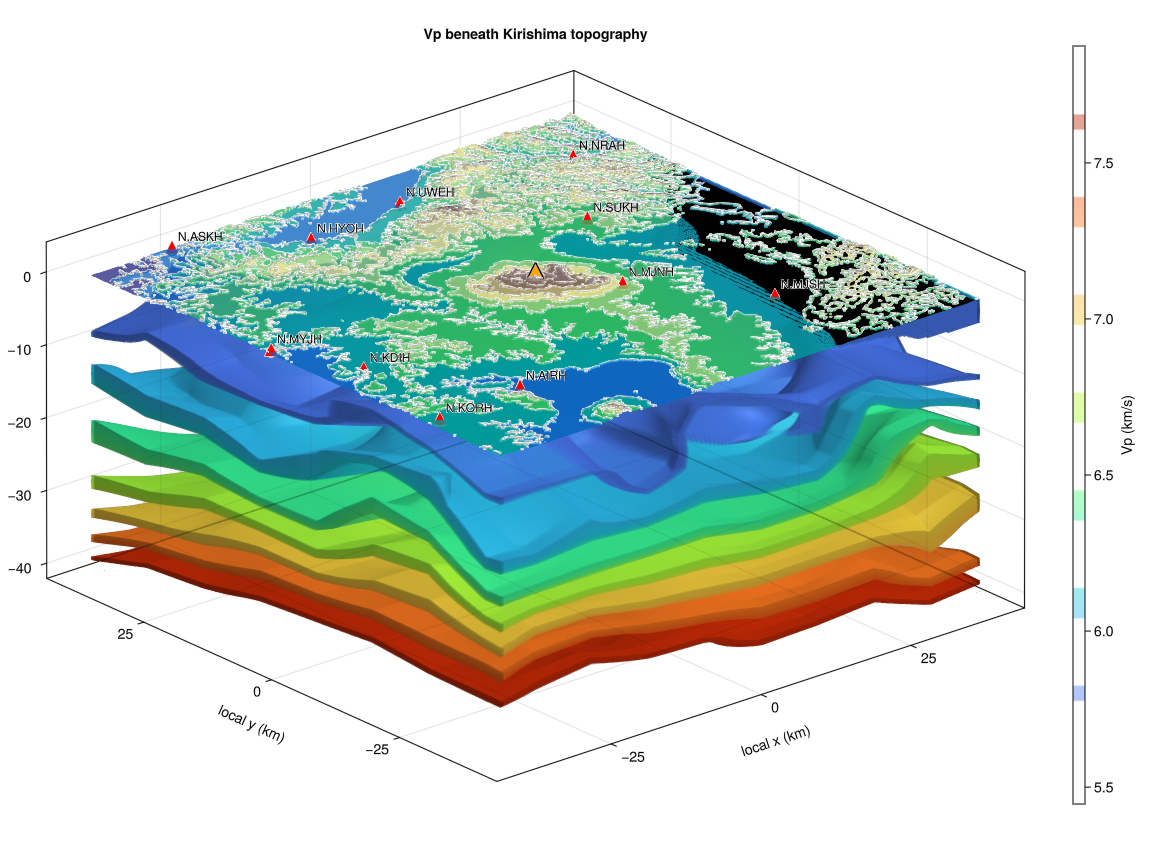

In [7]:
# Select :Vp or :Vs, and :isosurface or :volume.
velocityComponent = :Vp
velocityRenderMode = :isosurface

velocityField = if velocityComponent === :Vp
    seismicModel3D.Vpv
elseif velocityComponent === :Vs
    seismicModel3D.Vsv
else
    error("velocityComponent must be :Vp or :Vs")
end

# Mask air; the topographic surface is rendered independently.
solidVelocity = material .& isfinite.(velocityField) .& (velocityField .> 0)
velocityValues = velocityField[solidVelocity]
isempty(velocityValues) && error("No positive solid velocity values to plot")
velocityColorRange = quantile(velocityValues, (0.02, 0.98))
velocityForPlot = Float32.(velocityField)
velocityForPlot[.!solidVelocity] .= NaN32
# Makie VolumeLike coordinates are bounding endpoints, not full vectors.
xVolumeLimits = (first(x), last(x))
yVolumeLimits = (first(y), last(y))
zVolumeLimits = (first(z), last(z))

velocity3DFigure = Figure(size=(1150, 850))
velocity3DAxis = Axis3(
    velocity3DFigure[1, 1];
    xlabel="local x (km)", ylabel="local y (km)", zlabel="elevation (km)",
    title="$(velocityComponent) beneath Kirishima topography",
    aspect=:data,
)

velocityPlot = if velocityRenderMode === :isosurface
    contour!(
        velocity3DAxis,
        xVolumeLimits, yVolumeLimits, zVolumeLimits, velocityForPlot;
        levels=range(velocityColorRange...; length=7),
        colormap=:turbo, colorrange=velocityColorRange,
        alpha=0.42, transparency=true,
    )
elseif velocityRenderMode === :volume
    volume!(
        velocity3DAxis,
        xVolumeLimits, yVolumeLimits, zVolumeLimits, velocityForPlot;
        algorithm=:mip, colormap=:turbo,
        colorrange=velocityColorRange, transparency=true,
    )
else
    error("velocityRenderMode must be :isosurface or :volume")
end

# Translucent shaded relief exposes the velocity structure below it.
surface!(
    velocity3DAxis, x, y, topography;
    color=topography, colormap=:terrain,
    colorrange=extrema(topography), alpha=0.78, transparency=true,
)
contour3d!(
    velocity3DAxis, x, y, topography;
    levels=range(extrema(topography)...; length=12),
    color=(:black, 0.30), linewidth=0.8,
)

plot_stations!(
    velocity3DAxis, niedStations, boxGrids3D;
    units=:km, show_boreholes=true, labels=true,
)
scatter!(velocity3DAxis, [summitX], [summitY], [summitZ + 0.08];
    marker=:utriangle, markersize=20, color=:orange,
    strokecolor=:black, strokewidth=1.5)
Colorbar(velocity3DFigure[1, 2], velocityPlot;
    label="$(velocityComponent) (km/s)")
velocity3DFigure


## Two- and three-dimensional domains and boundaries

The 2D case is built along the same local x direction and is intended for rapid boundary-condition development. Boundary geometry is stored as an extension of each `boxGrids` named tuple rather than by mutating individual immutable `GeoPoint` values. Cerjan padding is already consumed by `numericalOperatorConstruction`; free-surface points and normals are routed into its geometry, while replacement of the corresponding PDE rows by the symbolic traction residual is kept as the next explicit implementation step.

In [8]:
# Fast 2D x-z model through the same Kirishima centre.
boxGrids2D = constructLocalBox(
    p0, Δx, Δz,
    -horizontalHalfWidth, horizontalHalfWidth,
    altMin, altMax,
)
modelCacheName2D = "seismicModel2D_Kirishima_10km_NIED_$(velocitySourceKey)"
seismicModel2D = lazyProduceOrLoad(
    modelCacheName2D,
    getParamsAndTopo,
    boxGrids2D.allGridsInGeoPoints,
    boxGrids2D.effectiveRadii,
    0.1;
    velocity_model=:NIED,
    nied_source=niedVelocitySource,
    nied_confidence_max=0.8,
    nied_outside=:planet1D,
    nied_low_confidence=:planet1D,
)

material2D = (seismicModel2D.ρ .> air_density_cutoff) .&
             (seismicModel2D.Vsv .> 0)
material3D = material .& (seismicModel3D.Vsv .> 0)

# User-controlled padding, expressed in grid points for each axis.
# 2D order: (x, z); 3D order: (x, y, z). The upper z width is zero
# because that side is the physical traction-free topography.
cerjan2D = CerjanBoundarySpec(
    (12, 12),  # lower x, lower z
    (12, 0);   # upper x, upper z
    damping=0.0053,
)
cerjan3D = CerjanBoundarySpec(
    (12, 12, 12),  # lower x, y, z
    (12, 12, 0);   # upper x, y, z
    damping=0.0053,
)

boundaryGeometry2D = boundary_geometry(
    material2D,
    (boxGrids2D.Δx, boxGrids2D.Δz);
    cerjan=cerjan2D,
)
boundaryGeometry3D = boundary_geometry(
    material3D,
    (boxGrids3D.Δx, boxGrids3D.Δy, boxGrids3D.Δz);
    cerjan=cerjan3D,
)

# NamedTuple extension: coordinates remain unchanged and the boundary points
# and normals remain aligned with their corresponding material grids.
boxGrids2D = (; boxGrids2D..., boundaryGeometry=boundaryGeometry2D)
boxGrids3D = (; boxGrids3D..., boundaryGeometry=boundaryGeometry3D)

# Symbolic traction residuals σ⋅n=0, analogous to famousEquations(...).
freeSurfaceEquation2D = famousBoundaryConditions("elasticTractionFree2D")
freeSurfaceEquation3D = famousBoundaryConditions("elasticTractionFree3D")

comparisonTable = Markdown.parse("""
| case | physical grid | elastic cells | free-surface points | Cerjan lower | Cerjan upper |
|:--|--:|--:|--:|:--|:--|
| 2D | `$(size(material2D))` | `$(count(material2D))` | `$(length(boundaryGeometry2D.free_surface.points))` | `$(cerjan2D.lower)` | `$(cerjan2D.upper)` |
| 3D | `$(size(material3D))` | `$(count(material3D))` | `$(length(boundaryGeometry3D.free_surface.points))` | `$(cerjan3D.lower)` | `$(cerjan3D.upper)` |
""")
display(comparisonTable)

@show first(boundaryGeometry2D.free_surface.points)
@show first(boundaryGeometry2D.free_surface.normals)
@show cerjan_padding(cerjan2D) cerjan_padding(cerjan3D)


centreOption = "p0"
Loading from ./tmp/seismicModel2D_Kirishima_10km_NIED_67f23ae0694b.jld2


| case |     physical grid | elastic cells | free-surface points | Cerjan lower   | Cerjan upper  |
|:---- | -----------------:| -------------:| -------------------:|:-------------- |:------------- |
| 2D   |      `(401, 211)` |       `81086` |               `401` | `(12, 12)`     | `(12, 0)`     |
| 3D   | `(401, 401, 211)` |    `32440429` |            `160801` | `(12, 12, 12)` | `(12, 12, 0)` |


first(boundaryGeometry2D.free_surface.points) = CartesianIndex(1, 200)
first(boundaryGeometry2D.free_surface.normals) = [-0.0, 1.0]
cerjan_padding(cerjan2D) = [12 12; 12 0]
cerjan_padding(cerjan3D) = [12 12 12; 12 12 0]


2×3 Matrix{Int64}:
 12  12  12
 12  12   0

## Two-dimensional elastic-wave propagation

This faster development case uses the same NIED/topographic section, a source approximately 10 km below the centre, three spatial points, three time levels and `supplementaryOrder = 2`. Cerjan cells are appended outside the physical sides and bottom. The material/air stress flux is set to zero at the stair-step topography; `famousBoundaryConditions("elasticTractionFree2D")` supplies the corresponding smooth-normal symbolic residual for the OPT boundary-row implementation.

In [ ]:
# Construct the requested three-point OPT recipe. A modest stride keeps this
# development operator quick; the explicit propagation below uses the full grid.
buildOPT2DOperator = true
opt2DStride = 4
optRecipe2D = nothing
optNumerical2D = nothing
optPrepared2D = nothing

if buildOPT2DOperator
    opt2DParameters = Dict{String,Any}(
        "famousEquationType" => "2DsismoTimeIsoHetero",
        "Δ" => (1.0, 1.0, 1.0),
        "orderBtime" => 1,
        "orderBspace" => 1,
        "pointsInSpace" => 3,
        "pointsInTime" => 3,
        "supplementaryOrder" => 2,
        "fieldItpl" => (ptsSpace=1, ptsTime=1, offsetSpace=1.0,
                         offsetTime=1, YorderBspace=-1, YorderBtime=-1),
        "materItpl" => (ptsSpace=1, ptsTime=1, offsetSpace=1.0,
                        offsetTime=1, YorderBspace=-1, YorderBtime=-1),
        "recipe_backend" => KernelAbstractions.CPU(),
    )
    optRecipe2D = makeOPTsemiSymbolic(opt2DParameters)
    ixOPT2D = 1:opt2DStride:size(material2D, 1)
    izOPT2D = 1:opt2DStride:size(material2D, 2)
    vp2 = Float64.(seismicModel2D.Vpv[ixOPT2D, izOPT2D]) .* 1e3
    vs2 = Float64.(seismicModel2D.Vsv[ixOPT2D, izOPT2D]) .* 1e3
    solid2 = material2D[ixOPT2D, izOPT2D]
    Δspace2 = opt2DStride * boxGrids2D.Δx
    dt2 = 0.20 * Δspace2 / (sqrt(2) * maximum(vp2[solid2]))
    # Same nondimensionalization as propagateInside_run.ipynb. Void cells
    # are pinned algebraically, so they must not receive a fictitious density.
    μ2 = vs2.^2 .* (dt2 / Δspace2)^2
    λ2 = (vp2.^2 .- 2 .* vs2.^2) .* (dt2 / Δspace2)^2
    ρ2 = Float64.(solid2)
    λ2[.!solid2] .= 0; μ2[.!solid2] .= 0
    optBC2D = boundary_geometry(
        solid2, (Δspace2, Δspace2);
        free_surface_mode=:dietrich,
        cerjan=CerjanBoundarySpec(
            (cld(cerjan2D.lower[1], opt2DStride), cld(cerjan2D.lower[2], opt2DStride)),
            (cld(cerjan2D.upper[1], opt2DStride), cld(cerjan2D.upper[2], opt2DStride));
            damping=cerjan2D.damping,
        ),
    )
    models2 = [ρ2, λ2, μ2]
    points2 = getModelPoints(models2[1], 3,
        optRecipe2D["recette"].numbersOfTheSystem.numbersOfTheSystemL.timeMarching)
    family2 = (models=models2, modelPoints=points2,
               Δ=(1.0, 1.0, 1.0), modelName="Kirishima_OPT2D")
    optNumerical2D = numericalOperatorConstruction(Dict{String,Any}(
        "optRec" => optRecipe2D, "modelFam" => family2,
        "absorbingBoundaries" => nothing, "maskedRegionInSpace" => nothing,
        "boundaryConditions" => optBC2D, "representation" => "matrixfree",
    ))["numOperators"]
    # The stable Dietrich mirror closure used in propagateInside_run is
    # applied inside prepareLinearSystem; :traction remains experimental.
    optPrepared2D = prepareLinearSystem(optNumerical2D;
        free_surface_spacing=(1.0, 1.0))
    @assert length(optNumerical2D.numericalOperators.left.geometry.freeSurfaceBoundary.points) ==
            length(optBC2D.free_surface.points)
    @assert !isempty(optPrepared2D.free_surface_rows)
    @assert !isempty(optPrepared2D.void_rows)
end


In [ ]:
# Physical-grid coordinates in metres.
x2D = [p.xz[1] for p in boxGrids2D.allGridsInCartesian[:, 1]]
z2D = [p.xz[2] for p in boxGrids2D.allGridsInCartesian[1, :]]
elasticConfig2D = ElasticThreePointConfig2D(
    pointsInSpace=3, pointsInTime=3, supplementaryOrder=2, cfl=0.38,
)
elasticState2D = prepare_elastic_wave_2d(
    seismicModel2D, (boxGrids2D.Δx, boxGrids2D.Δz);
    material_mask=material2D,
    boundary_conditions=boundaryGeometry2D,
    config=elasticConfig2D,
)
waveCoordinates2D = elastic_wave_coordinates(x2D, z2D, elasticState2D)

# Epicentre at local x=-10 km; the hypocentre is placed below the actual
# topographic surface rather than relative to z=0.
epicentreX2D = -10e3
sourceDepthBelowTopography2D = 2e3
sourceIX2D = argmin(abs.(x2D .- epicentreX2D))
surfacePointAtSource2D = boundaryGeometry2D.free_surface.points[sourceIX2D]
surfaceAltitudeAtSource2D = z2D[surfacePointAtSource2D[2]]
sourceIZ2D = argmin(abs.(z2D .-
    (surfaceAltitudeAtSource2D - sourceDepthBelowTopography2D)))
sourcePhysical2D = CartesianIndex(sourceIX2D, sourceIZ2D)
@assert material2D[sourcePhysical2D]
source2D = sourcePhysical2D + CartesianIndex(Tuple(elasticState2D.padding[1, :]))
simulationDuration2D = 30.0       # seconds; includes several boundary reflections
outputSampling2D = 0.10           # seconds between stored/video frames
# Same resolved-source convention as propagateInside_run.ipynb.
sourceFrequency2D = median(seismicModel2D.Vsv[material2D]) * 1e3 /
                    (10 * boxGrids2D.Δx)
sourceDelay2D = min(12 * elasticState2D.dt, 0.25 * simulationDuration2D)
sourceAmplitude2D = 1.0
numberSteps2D = ceil(Int, simulationDuration2D / elasticState2D.dt)
frameStride2D = max(1, round(Int, outputSampling2D / elasticState2D.dt))

uxFrames2D = Matrix{Float32}[copy(elasticState2D.ux)]
uzFrames2D = Matrix{Float32}[copy(elasticState2D.uz)]
frameTimes2D = Float64[0.0]
for step in 1:numberSteps2D
    step_elastic_wave_2d!(elasticState2D)
    elasticWave2D.add_ricker_source!(elasticState2D, source2D;
        f0=sourceFrequency2D, t0=sourceDelay2D,
        amplitude=sourceAmplitude2D, component=:z)
    if step == 1 || step % frameStride2D == 0 || step == numberSteps2D
        push!(uxFrames2D, copy(elasticState2D.ux))
        push!(uzFrames2D, copy(elasticState2D.uz))
        push!(frameTimes2D, elasticState2D.time)
    end
end
uxHistory2D = cat(uxFrames2D...; dims=3)
uzHistory2D = cat(uzFrames2D...; dims=3)
@show elasticState2D.dt numberSteps2D length(frameTimes2D)


In [ ]:
# Propagate with the assembled OPT operator on its development grid.
# Both solvers use the same hypocentre, Ricker frequency and duration.
if buildOPT2DOperator
    optPadding2D = cerjan_padding(optBC2D.cerjan)
    xOPT2DPhysical = x2D[ixOPT2D]
    zOPT2DPhysical = z2D[izOPT2D]
    xOPT2DWhole = range(first(xOPT2DPhysical) - optPadding2D[1,1] * Δspace2;
        step=Δspace2, length=optPrepared2D.spaceShape[1])
    zOPT2DWhole = range(first(zOPT2DPhysical) - optPadding2D[1,2] * Δspace2;
        step=Δspace2, length=optPrepared2D.spaceShape[2])
    sourceOPT2D = CartesianIndex(
        argmin(abs.(xOPT2DPhysical .- epicentreX2D)) + optPadding2D[1,1],
        argmin(abs.(zOPT2DPhysical .-
            (surfaceAltitudeAtSource2D - sourceDepthBelowTopography2D))) +
            optPadding2D[1,2],
    )
    numberStepsOPT2D = ceil(Int, simulationDuration2D / dt2)
    outputStrideOPT2D = max(1, round(Int, outputSampling2D / dt2))
    numberSourceTimes2D = numberStepsOPT2D +
        optPrepared2D.timePointsUsedForOneStep - 1
    sourceFullOPT2D = zeros(Float64, optPrepared2D.NforcePoints,
        optPrepared2D.NForceField, numberSourceTimes2D)
    sourceLinearOPT2D = LinearIndices(optPrepared2D.spaceShape)[sourceOPT2D]
    sourceTimesOPT2D = (0:numberSourceTimes2D-1) .* dt2
    sourceDelayOPT2D = sourceDelay2D
    sourceWaveletOPT2D = @. (1 - 2(π * sourceFrequency2D *
        (sourceTimesOPT2D - sourceDelayOPT2D))^2) *
        exp(-(π * sourceFrequency2D *
        (sourceTimesOPT2D - sourceDelayOPT2D))^2)
    # M11 moment source, matching the working elastic configuration in
    # propagateInside_run.ipynb. The four force fields are M11,M12,M21,M22.
    @assert optPrepared2D.NForceField == 4
    sourceFullOPT2D[sourceLinearOPT2D, 1, :] .= sourceWaveletOPT2D
    optPropagation2D = propagateLinearSystem(
        optPrepared2D, numberStepsOPT2D, dt2;
        sourceFull=sourceFullOPT2D, output_stride=outputStrideOPT2D,
        blowup_limit=1e8,
    )
    @assert !optPropagation2D.stopped_early "OPT2D stopped early; do not build misleading seismograms"
    uxHistoryOPT2D = optPropagation2D.history[:, :, 1, :]
    uzHistoryOPT2D = optPropagation2D.history[:, :, 2, :]
    frameTimesOPT2D = optPropagation2D.times
    @show size(uzHistoryOPT2D) length(optPrepared2D.free_surface_rows)
    @show length(optPrepared2D.void_rows) last(frameTimesOPT2D)
end


In [ ]:
# Dimension-independent output requests. Coordinate names and dimensionality
# come from this NamedTuple rather than being hard-coded in fieldOutput.jl.
# The keys can be the actual Symbolics fields returned by famousEquations.
recipeFields2D = isnothing(optRecipe2D) ? (:ux, :uz) : recipe_field_symbols(optRecipe2D)
waveFields2D = Dict(recipeFields2D[1] => uxHistory2D,
                    recipeFields2D[2] => uzHistory2D)
waveAxes2D = (x=waveCoordinates2D.x, z=waveCoordinates2D.z, t=frameTimes2D)
stationX, stationZ = 37.5, -123.4 # arbitrary off-grid receiver/voxel
shearStrainXZ = FieldExpression(:epsilon_xz, (fields, coordinates) ->
    0.5 .* (differentiate_field(fields[recipeFields2D[1]], coordinates, :z) .+
            differentiate_field(fields[recipeFields2D[2]], coordinates, :x)))
outputRequests2D = (
    FieldOutputRequest(recipeFields2D[2];
        selection=(x=(-10e3, 10e3, 200.0), t=(0.0, 30.0, 0.1)),
        label=:vertical_displacement, interpolation=:nearest),
    FieldOutputRequest(FieldDerivative(recipeFields2D[1], :x);
        selection=(x=stationX, z=stationZ, t=(0.0, 30.0, 0.1)),
        label=:du_x_dx_at_station, interpolation=:linear),
    FieldOutputRequest(FieldDerivative(recipeFields2D[2], :t);
        selection=(x=stationX, z=stationZ, t=(0.0, 30.0, 0.1)),
        label=:vertical_velocity_at_station, interpolation=:linear),
    FieldOutputRequest(shearStrainXZ;
        selection=(x=stationX, z=stationZ, t=(0.0, 30.0, 0.1)),
        interpolation=:linear),
)
waveOutputs2D = sample_field_output(waveFields2D, waveAxes2D, outputRequests2D)
@show [(output.label, size(output.values)) for output in waveOutputs2D]

# Surface seismograms from a derived quantity, not a stored field.
verticalVelocity2D = FieldExpression(
    :vertical_velocity,
    (fields, coordinates) -> differentiate_field(
        fields[recipeFields2D[2]], coordinates, :t),
)
receiverXTargets2D = [-20e3, -10e3, 0.0, 10e3, 20e3]
surfacePointsFD2D = map(receiverXTargets2D) do receiverX
    i = argmin(abs.(x2D .- receiverX))
    point = boundaryGeometry2D.free_surface.points[i]
    (x=x2D[i], z=z2D[point[2]])
end
receiverRequestsFD2D = [
    FieldOutputRequest(verticalVelocity2D;
        selection=(x=point.x, z=point.z),
        label="FD x=$(point.x * 1e-3) km", interpolation=:linear)
    for point in surfacePointsFD2D
]
seismogramsFD2D = sample_field_output(
    waveFields2D, waveAxes2D, receiverRequestsFD2D)

waveFieldsOPT2D = Dict(recipeFields2D[1] => uxHistoryOPT2D,
                       recipeFields2D[2] => uzHistoryOPT2D)
waveAxesOPT2D = (x=xOPT2DWhole, z=zOPT2DWhole, t=frameTimesOPT2D)
surfacePointsOPT2D = map(receiverXTargets2D) do receiverX
    iPhysical = argmin(abs.(xOPT2DPhysical .- receiverX))
    pointPhysical = optBC2D.free_surface.points[iPhysical]
    (x=xOPT2DPhysical[iPhysical], z=zOPT2DPhysical[pointPhysical[2]])
end
receiverRequestsOPT2D = [
    FieldOutputRequest(verticalVelocity2D;
        selection=(x=point.x, z=point.z),
        label="OPT x=$(point.x * 1e-3) km", interpolation=:linear)
    for point in surfacePointsOPT2D
]
seismogramsOPT2D = sample_field_output(
    waveFieldsOPT2D, waveAxesOPT2D, receiverRequestsOPT2D)

seismogramFigure2D = Figure(size=(1200, 650))
axisSeisFD2D = Axis(seismogramFigure2D[1, 1];
    xlabel="time (s)", ylabel="normalized trace + receiver offset",
    title="surface vertical velocity — FD")
axisSeisOPT2D = Axis(seismogramFigure2D[1, 2];
    xlabel="time (s)", title="surface vertical velocity — OPT2D")
for (receiver, output) in enumerate(seismogramsFD2D)
    trace = vec(output.values)
    scale = max(maximum(abs, trace), eps(Float64))
    lines!(axisSeisFD2D, output.coordinates.t,
        trace ./ scale .+ 2(receiver - 1);
        label="x=$(surfacePointsFD2D[receiver].x * 1e-3) km")
end
for (receiver, output) in enumerate(seismogramsOPT2D)
    trace = vec(output.values)
    scale = max(maximum(abs, trace), eps(Float64))
    lines!(axisSeisOPT2D, output.coordinates.t,
        trace ./ scale .+ 2(receiver - 1);
        label="x=$(surfacePointsOPT2D[receiver].x * 1e-3) km")
end
axislegend(axisSeisFD2D; position=:rb)
axislegend(axisSeisOPT2D; position=:rb)
seismogramFigure2D


In [ ]:
# Synchronized comparison. Amplitudes are normalized independently because
# the explicit acceleration and nondimensional OPT force use different units.
waveVideo2D = joinpath(flexopt_root, "data", "Kirishima_FD_vs_OPT2D.mp4")
scaleFD2D = max(maximum(abs, uzHistory2D), eps(Float32))
scaleOPT2D = max(maximum(abs, uzHistoryOPT2D), eps(Float64))
figure2D = Figure(size=(1450, 560))
surfaceX2D = x2D
surfaceZ2D = [z2D[point[2]] for point in boundaryGeometry2D.free_surface.points]
axisFD2D = Axis(figure2D[1, 1]; xlabel="local x (km)", ylabel="altitude (km)",
                aspect=DataAspect(),
                title="three-point FD")
axisOPT2D = Axis(figure2D[1, 2]; xlabel="local x (km)", ylabel="altitude (km)",
                 aspect=DataAspect(),
                 title="OPT2D, supplementaryOrder=2")
frameFD2D = Observable(uzHistory2D[:, :, 1] ./ scaleFD2D)
frameOPT2D = Observable(uzHistoryOPT2D[:, :, 1] ./ scaleOPT2D)
wavePlotFD2D = heatmap!(axisFD2D, waveCoordinates2D.x .* 1e-3,
    waveCoordinates2D.z .* 1e-3, frameFD2D;
    colormap=:balance, colorrange=(-1, 1))
heatmap!(axisOPT2D, xOPT2DWhole .* 1e-3, zOPT2DWhole .* 1e-3,
    frameOPT2D; colormap=:balance, colorrange=(-1, 1))
for axis in (axisFD2D, axisOPT2D)
    lines!(axis, surfaceX2D .* 1e-3, surfaceZ2D .* 1e-3;
        color=:black, linewidth=2.5, label="topography")
    scatter!(axis, [x2D[sourcePhysical2D[1]] * 1e-3],
        [z2D[sourcePhysical2D[2]] * 1e-3];
        color=:yellow, strokecolor=:black, strokewidth=1,
        marker=:star5, markersize=16)
    scatter!(axis, [point.x * 1e-3 for point in surfacePointsFD2D],
        [point.z * 1e-3 for point in surfacePointsFD2D];
        color=:red, marker=:utriangle, markersize=9)
end
Colorbar(figure2D[1, 3], wavePlotFD2D; label="normalized u_z")
record(figure2D, waveVideo2D, eachindex(frameTimes2D); framerate=25) do iframe
    timeHere = frameTimes2D[iframe]
    iframeOPT = argmin(abs.(frameTimesOPT2D .- timeHere))
    frameFD2D[] = uzHistory2D[:, :, iframe] ./ scaleFD2D
    frameOPT2D[] = uzHistoryOPT2D[:, :, iframeOPT] ./ scaleOPT2D
    axisFD2D.title = "FD — t=$(round(timeHere, digits=2)) s"
    axisOPT2D.title = "OPT2D — t=$(round(frameTimesOPT2D[iframeOPT], digits=2)) s"
end
@show waveVideo2D
figure2D


## Three-dimensional elastic-wave propagation

This explicit displacement solver uses three centered spatial points, three time levels and `supplementaryOrder = 0`. The NIED/planet1D `Vp`, `Vs`, density/material mask and real topography are reused directly. The current irregular-surface treatment is a stable zero-normal-gradient ghost approximation; exact traction-free conditions using `surface_normals` remain the next boundary-condition refinement.

In [14]:
elasticConfig = ElasticThreePointConfig(
    pointsInSpace=3,
    pointsInTime=3,
    supplementaryOrder=0,
    cfl=0.42,
    cerjan_width=12,
    cerjan_strength=0.015,
)

# Fluids and air are excluded from this elastic run. Their coupling can be
# handled later by a separate acoustic domain.
elasticMaterial = material .& (seismicModel3D.Vsv .> 0)
elasticState = prepare_elastic_wave_3d(
    seismicModel3D,
    (boxGrids3D.Δx, boxGrids3D.Δy, boxGrids3D.Δz);
    material_mask=elasticMaterial,
    config=elasticConfig,
    T=Float32,
)

# Vertical point force 1 km below the summit.
sourceIX = argmin(abs.(x .- summitX))
sourceIY = argmin(abs.(y .- summitY))
sourceDepth = 1.0 # km below local topography
sourceIZ = argmin(abs.(z .- (topography[sourceIX, sourceIY] - sourceDepth)))
sourceIndex = CartesianIndex(sourceIX, sourceIY, sourceIZ)
@assert elasticMaterial[sourceIndex]

sourceFrequency = 2.0 # Hz
sourceDelay = 1.2 / sourceFrequency
sourceAcceleration = 1.0e3 # arbitrary preview amplitude (m/s²)

@show elasticState.dt sourceIndex
@show elasticConfig.pointsInSpace elasticConfig.pointsInTime
@show elasticConfig.supplementaryOrder


elasticState.dt = 0.0059469207f0
sourceIndex = CartesianIndex(201, 201, 205)
elasticConfig.pointsInSpace = 3
elasticConfig.pointsInTime = 3
elasticConfig.supplementaryOrder = 0


0

In [15]:
# Keep only lightweight central slices rather than copying full 3D fields.
numberTimeSteps = 300
snapshotStride = 15
elasticSnapshots = NamedTuple[]
sourceYElastic = sourceIY

for timeStep in 1:numberTimeSteps
    step_elastic_wave_3d!(elasticState)
    elasticWave3D.add_ricker_source!(
        elasticState, sourceIndex;
        f0=sourceFrequency,
        t0=sourceDelay,
        amplitude=sourceAcceleration,
        component=:z,
    )
    if timeStep == 1 || timeStep % snapshotStride == 0
        push!(elasticSnapshots, (
            step=timeStep,
            time=Float64(elasticState.time),
            uz_xz=copy(@view elasticState.uz[:, sourceYElastic, :]),
        ))
    end
end

@show elasticState.time length(elasticSnapshots)
@show maximum(abs, elasticState.uz)


elasticState.time = 1.7840718f0
length(elasticSnapshots) = 21
maximum(abs, elasticState.uz) = 0.030147796f0


0.030147796f0

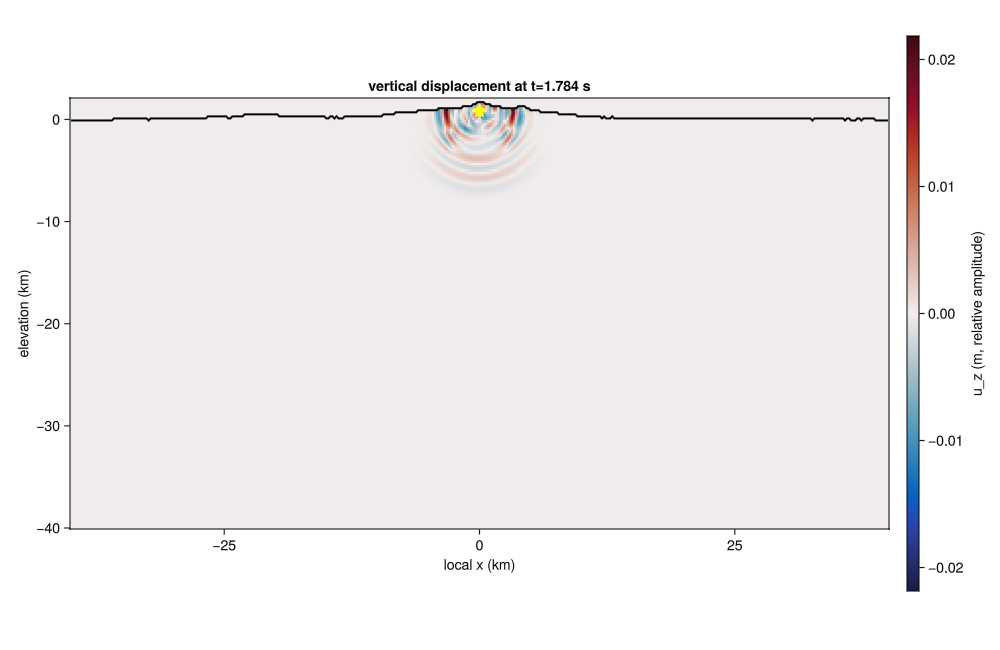

In [16]:
elasticSnapshot = last(elasticSnapshots)
elasticColorLimit = maximum(abs, elasticSnapshot.uz_xz)
elasticFigure = Figure(size=(1000, 650))
elasticAxis = Axis(
    elasticFigure[1, 1];
    xlabel="local x (km)", ylabel="elevation (km)",
    title="vertical displacement at t=$(round(elasticSnapshot.time; digits=3)) s",
    aspect=DataAspect(),
)
elasticPlot = heatmap!(
    elasticAxis, x, z, elasticSnapshot.uz_xz;
    colormap=:balance,
    colorrange=(-elasticColorLimit, elasticColorLimit),
)
# Topographic profile of the source-aligned y section.
lines!(elasticAxis, x, topography[:, sourceYElastic];
    color=:black, linewidth=2)
scatter!(elasticAxis, [x[sourceIX]], [z[sourceIZ]];
    marker=:star5, color=:yellow, strokecolor=:black, markersize=18)
Colorbar(elasticFigure[1, 2], elasticPlot; label="u_z (m, relative amplitude)")
elasticFigure


## OPT3D comparison through `famousEquations`

Set `runOPT3DComparison = true` to build and run `3DsismoTimeIso`. The symbolic recipe uses the same three spatial points, three time levels and `supplementaryOrder = 0`. Because OPT forms and factorizes a global sparse system, the comparison defaults to a grid decimated by five; the explicit solver above remains on the complete grid.

In [17]:
# Remove :OPT3D from this tuple to run only the full-grid explicit solver.
waveSolverBackends = (:explicit3, :OPT3D)
runOPT3DComparison = :OPT3D in waveSolverBackends
optStride = 5
optNumberTimeSteps = 120
optSnapshotStride = 10

if runOPT3DComparison
    optIndicesX = 1:optStride:size(seismicModel3D.ρ, 1)
    optIndicesY = 1:optStride:size(seismicModel3D.ρ, 2)
    optIndicesZ = 1:optStride:size(seismicModel3D.ρ, 3)
    xOPT, yOPT, zOPT = x[optIndicesX], y[optIndicesY], z[optIndicesZ]

    ρOPT = Float64.(seismicModel3D.ρ[optIndicesX, optIndicesY, optIndicesZ]) .* 1e3
    vpOPT = Float64.(seismicModel3D.Vpv[optIndicesX, optIndicesY, optIndicesZ]) .* 1e3
    vsOPT = Float64.(seismicModel3D.Vsv[optIndicesX, optIndicesY, optIndicesZ]) .* 1e3
    solidOPT = (ρOPT .> 10.0) .& (vsOPT .> 0)
    optCerjanWidth = cld(12, optStride)
    optSpacing = optStride * boxGrids3D.Δx
    optBoundaryGeometry3D = boundary_geometry(
        solidOPT,
        (optSpacing, optSpacing, optSpacing);
        cerjan=CerjanBoundarySpec(
            (optCerjanWidth, optCerjanWidth, optCerjanWidth),
            (optCerjanWidth, optCerjanWidth, 0);
            damping=cerjan3D.damping,
        ),
    )
    ρReferenceOPT = median(ρOPT[solidOPT])

    dtOPT = 0.32 * optSpacing / (sqrt(3) * maximum(vpOPT[solidOPT]))
    μOPT = ρOPT .* vsOPT.^2
    λOPT = ρOPT .* vpOPT.^2 .- 2 .* μOPT

    # Dimensionless coefficients for Δ = (1,1,1,1). A small positive
    # inertia in air keeps the global OPT matrix nonsingular while λ=μ=0.
    ρModelOPT = max.(ρOPT ./ ρReferenceOPT, 1e-3)
    λModelOPT = (λOPT ./ ρReferenceOPT) .* (dtOPT / optSpacing)^2
    μModelOPT = (μOPT ./ ρReferenceOPT) .* (dtOPT / optSpacing)^2
    λModelOPT[.!solidOPT] .= 0.0
    μModelOPT[.!solidOPT] .= 0.0

    famousEquationTypeOPT = "3DsismoTimeIso"
    ΔOPT = (1.0, 1.0, 1.0, 1.0)
    orderBtimeOPT = 1
    orderBspaceOPT = -1
    pointsInSpaceOPT = 3
    pointsInTimeOPT = 3
    supplementaryOrderOPT = 0
    fieldItplOPT = (ptsSpace=1, ptsTime=1, offsetSpace=1.0,
        offsetTime=1, YorderBspace=-1, YorderBtime=1)
    materItplOPT = fieldItplOPT
    recipe_backendOPT = KernelAbstractions.CPU()

    optRecipeParameters = Dict{String,Any}(
        "famousEquationType" => famousEquationTypeOPT,
        "Δ" => ΔOPT,
        "orderBtime" => orderBtimeOPT,
        "orderBspace" => orderBspaceOPT,
        "pointsInSpace" => pointsInSpaceOPT,
        "pointsInTime" => pointsInTimeOPT,
        "supplementaryOrder" => supplementaryOrderOPT,
        "fieldItpl" => fieldItplOPT,
        "materItpl" => materItplOPT,
        "recipe_backend" => recipe_backendOPT,
    )
    optRecipe3D = makeOPTsemiSymbolic(optRecipeParameters)
    optModels3D = [ρModelOPT, λModelOPT, μModelOPT]
    optModelPoints3D = getModelPoints(
        optModels3D[1], pointsInTimeOPT,
        optRecipe3D["recette"].numbersOfTheSystem.numbersOfTheSystemL.timeMarching,
    )
    optModelFamily3D = (
        models=optModels3D, modelPoints=optModelPoints3D,
        Δ=ΔOPT, modelName="Kirishima_OPT3D_stride$(optStride)",
    )
    optNumericalParameters = Dict{String,Any}(
        "optRec" => optRecipe3D,
        "modelFam" => optModelFamily3D,
        "absorbingBoundaries" => nothing,
        "maskedRegionInSpace" => nothing,
        "boundaryConditions" => optBoundaryGeometry3D,
        "representation" => "matrixfree",
    )
    optNumerical3D = numericalOperatorConstruction(optNumericalParameters)["numOperators"]
    optPrepared3D = prepareLinearSystem(optNumerical3D)
    optPadding3D = cerjan_padding(optBoundaryGeometry3D.cerjan)
    optStepKm = optSpacing * 1e-3
    xOPTWhole = range(
        first(xOPT) - optPadding3D[1,1] * optStepKm;
        step=optStepKm, length=optPrepared3D.spaceShape[1],
    )
    zOPTWhole = range(
        first(zOPT) - optPadding3D[1,3] * optStepKm;
        step=optStepKm, length=optPrepared3D.spaceShape[3],
    )

    @assert optPrepared3D.NField == 3
    @assert optPrepared3D.NForceField == 6
    @assert optPrepared3D.timePointsUsedForOneStep == 3
    @assert length(optPrepared3D.left_operator.geometry.freeSurfaceBoundary.points) ==
            length(optBoundaryGeometry3D.free_surface.points)
    @show optPrepared3D.spaceShape size(optPrepared3D.A_unknown)
    @show nnz(optPrepared3D.A_unknown) dtOPT
end


(vars, iVars) = ((ρ(x, y, z), λ(x, y, z), μ(x, y, z)), 1)
(vars, iVars) = ((ρ(x, y, z), λ(x, y, z), μ(x, y, z)), 2)
(vars, iVars) = ((ρ(x, y, z), λ(x, y, z), μ(x, y, z)), 3)
(vars, iVars) = ((ρ(x, y, z), λ(x, y, z), μ(x, y, z)), 1)
(vars, iVars) = ((ρ(x, y, z), λ(x, y, z), μ(x, y, z)), 2)
(vars, iVars) = ((ρ(x, y, z), λ(x, y, z), μ(x, y, z)), 3)
pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{4, Int64}[[1, 1, 1, 1] [1, 2, 1, 1] [1, 3, 1, 1]; [2, 1, 1, 1] [2, 2, 1, 1] [2, 3, 1, 1]; [3, 1, 1, 1] [3, 2, 1, 1] [3, 3, 1, 1];;; [1, 1, 2, 1] [1, 2, 2, 1] [1, 3, 2, 1]; [2, 1, 2, 1] [2, 2, 2, 1] [2, 3, 2, 1]; [3, 1, 2, 1] [3, 2, 2, 1] [3, 3, 2, 1];;; [1, 1, 3, 1] [1, 2, 3, 1] [1, 3, 3, 1]; [2, 1, 3, 1] [2, 2, 3, 1] [2, 3, 3, 1]; [3, 1, 3, 1] [3, 2, 3, 1] [3, 3, 3, 1];;;; [1, 1, 1, 2] [1, 2, 1, 2] [1, 3, 1, 2]; [2, 1, 1, 2] [2, 2, 1, 2] [2, 3, 1, 2]; [3, 1, 1, 2] [3, 2, 1, 2] [3, 3, 1, 2];;; [1, 1, 2, 2] [1, 2, 2, 2] [1, 3, 2, 2]; [2, 1, 2, 2] [2, 2, 2, 2] [2, 3, 2, 2]; 

[ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/WYYKKIntegralSymbolic/WYYKKIntegralSymbolic_25090681.jld2 does not exist. Producing it now...


LoadError: MethodError: no method matching backend_show(::GLMakie.Screen{GLFW.Window}, ::IOStream, ::MIME{Symbol("application/pdf")}, ::Scene)
The function `backend_show` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  backend_show([91m::CairoMakie.Screen{CairoMakie.PDF}[39m, ::IO, ::MIME{Symbol("application/pdf")}, ::Scene)
[0m[90m   @[39m [35mCairoMakie[39m [90m~/.julia/packages/CairoMakie/Yu6dt/src/[39m[90m[4mdisplay.jl:99[24m[39m
[0m  backend_show(::Any, ::IO, [91m::MIME{Symbol("text/plain")}[39m, ::Scene)
[0m[90m   @[39m [35mMakie[39m [90m~/.julia/packages/Makie/FUAHr/src/[39m[90m[4mdisplay.jl:224[24m[39m
[0m  backend_show(::MakieScreen, ::IO, [91m::MIME{Symbol("image/png")}[39m, ::Scene)
[0m[90m   @[39m [35mMakie[39m [90m~/.julia/packages/Makie/FUAHr/src/[39m[90m[4mdisplay.jl:486[24m[39m
[0m  ...


In [ ]:
function propagate_opt3d(
    prepared, numberTimeSteps, sourceIndex, dt;
    f0=2.0, t0=0.6, amplitude=1e-3, snapshotStride=10,
)
    prepared.timePointsUsedForOneStep == 3 ||
        error("OPT3D comparison requires three time levels")
    nPoints, nFields = prepared.NpointsSpace, prepared.NField
    knownField = zeros(Float64, nPoints, nFields, 2)
    knownForce = zeros(Float64, prepared.NforcePoints, prepared.NForceField, 3)
    unknown = zeros(Float64, nPoints, nFields)
    knownInputs = zeros(Float64, length(knownField) + length(knownForce))
    rightHandSide = copy(prepared.b_template)
    factorization = lu(sparse(prepared.A_unknown))
    sourceLinear = LinearIndices(prepared.spaceShape)[sourceIndex]
    sourceSignal(t) = begin
        a = π * f0 * (t - t0)
        (1 - 2a^2) * exp(-a^2)
    end
    snapshots = NamedTuple[]

    for step in 1:numberTimeSteps
        fill!(knownForce, 0.0)
        for timeSlot in 1:3
            t = (step + timeSlot - 2) * dt
            # M33 is the sixth independent symmetric moment component.
            knownForce[sourceLinear, 6, timeSlot] =
                amplitude * sourceSignal(t)
        end
        nKnown = length(knownField)
        knownInputs[1:nKnown] .= vec(knownField)
        knownInputs[nKnown+1:end] .= vec(knownForce)
        prepared.b_fun!(rightHandSide, knownInputs)
        unknown .= reshape(factorization \ rightHandSide, nPoints, nFields)
        all(isfinite, unknown) || error("OPT3D produced a non-finite field at step $step")

        knownField[:, :, 1] .= knownField[:, :, 2]
        knownField[:, :, 2] .= unknown
        if step == 1 || step % snapshotStride == 0
            volume = reshape(@view(unknown[:, 3]), prepared.spaceShape)
            push!(snapshots, (
                step=step, time=step * dt,
                uz_xz=copy(@view volume[:, sourceIndex[2], :]),
            ))
        end
    end
    return (; snapshots, final=copy(unknown))
end

if runOPT3DComparison
    sourceIndexOPT = CartesianIndex(
        argmin(abs.(xOPT .- summitX)),
        argmin(abs.(yOPT .- summitY)),
        argmin(abs.(zOPT .- (summitZ - sourceDepth))),
    )
    sourceIndexOPTWhole = optPrepared3D.left_operator.geometry.conv.model2whole(
        sourceIndexOPT,
    )
    opt3DResult = propagate_opt3d(
        optPrepared3D, optNumberTimeSteps, sourceIndexOPTWhole, dtOPT;
        f0=sourceFrequency, t0=sourceDelay,
        snapshotStride=optSnapshotStride,
    )
    @show sourceIndexOPT sourceIndexOPTWhole length(opt3DResult.snapshots)
    @show maximum(abs, opt3DResult.final)
end


In [ ]:
if runOPT3DComparison
    explicitComparison = last(elasticSnapshots)
    optComparison = last(opt3DResult.snapshots)
    # Source normalizations differ (point acceleration versus M33 moment),
    # so compare wavefront shape after independent peak normalization.
    explicitNormalized = explicitComparison.uz_xz ./
        max(maximum(abs, explicitComparison.uz_xz), eps(Float32))
    optNormalized = optComparison.uz_xz ./
        max(maximum(abs, optComparison.uz_xz), eps(Float64))
    comparisonFigure = Figure(size=(1200, 520))
    explicitAxis = Axis(comparisonFigure[1, 1];
        xlabel="x (km)", ylabel="z (km)", aspect=DataAspect(),
        title="explicit 3-point, t=$(round(explicitComparison.time; digits=3)) s")
    optAxis = Axis(comparisonFigure[1, 2];
        xlabel="x (km)", ylabel="z (km)", aspect=DataAspect(),
        title="OPT3D famousEquation, t=$(round(optComparison.time; digits=3)) s")
    heatmap!(explicitAxis, x, z, explicitNormalized;
        colormap=:balance, colorrange=(-1, 1))
    optHeatmap = heatmap!(optAxis, xOPTWhole, zOPTWhole, optNormalized;
        colormap=:balance, colorrange=(-1, 1))
    lines!(explicitAxis, x, topography[:, sourceYElastic]; color=:black)
    Colorbar(comparisonFigure[1, 3], optHeatmap; label="normalized u_z")
    comparisonFigure
end


In [ ]:
# Global alternative (EarthScope/IRIS-compatible FDSN service).
# Channel-level queries preserve instrument depth. Uncomment when needed.
# fdsnStations = fetch_fdsn_stations(
#     stationBounds;
#     network="*",
#     channel="HHZ,BHZ,EHZ",
# )
# fdsnOverlay = plot_stations!(ax, fdsnStations, boxGrids3D; units=:km)
# fig